# Showcase — real data, real tables, real charts

This notebook is **committed with its outputs**: what you see on GitHub is what the pipeline produces.
Data: vendored `data/*.csv` (offline). One task per cell; run top-to-bottom.

## 0. Imports — plotting plus the same à la carte library calls

In [1]:
# NOTE: this notebook is saved WITH outputs (charts/tables render on GitHub).
# Re-running it rewrites those outputs — keep cells deterministic (fixed seeds).
from pathlib import Path  # locate vendored data/ whatever the kernel cwd is

import matplotlib.pyplot as plt  # inline charts (the CLI instead writes plotly HTML)
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay  # confusion matrix, one call
from sklearn.pipeline import Pipeline  # preprocess + model as one object

from ml_boilerplate.config import Config, ModelConfig  # code-built config, no YAML
from ml_boilerplate.crossval import run_cv  # k-fold CV with per-fold table
from ml_boilerplate.distributions import data_distributions  # stored profile for drift
from ml_boilerplate.eda import profile_dataframe  # missing-value summary table
from ml_boilerplate.evaluation import evaluate_on_test  # metrics tables
from ml_boilerplate.io import read_table  # csv, local or URL
from ml_boilerplate.model import build_model  # estimator by registry name
from ml_boilerplate.monitor import check_drift  # PSI drift table
from ml_boilerplate.tasks import get_task  # splitter + preprocessor + metrics per task
from ml_boilerplate.validation import split_train_val_test  # train/val/test in one call

DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents]
               if (p / 'data' / 'mpg.csv').exists()), Path('data'))
plt.style.use('seaborn-v0_8-whitegrid')
print('data dir:', DATA.resolve())

data dir: /home/rajindersingh/personal_work/ml_boiler_plate/data


## 1. Load Penguins — 344 rows, 3 species, genuine missing values (the interesting bits are real)

In [2]:
# Palmer Penguins: bill/flipper/mass measurements + island/sex categories.
# Target = species (Adelie/Chinstrap/Gentoo). Small enough to print whole.
pg = read_table(str(DATA / 'penguins.csv'))
display(pg.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 2. Missing-value table — report, don't silently drop

In [3]:
# profile_dataframe returns plain dicts; here we frame just the missing block
# and filter to columns that actually have gaps. Interview line: 'bill and
# body-mass miss 2 rows each, sex misses 11 — impute, don't drop'.
prof = profile_dataframe(pg)
display(pd.DataFrame(prof['missing']).T.query('count > 0'))

,count,pct
bill_length_mm,2.0,0.58
bill_depth_mm,2.0,0.58
flipper_length_mm,2.0,0.58
body_mass_g,2.0,0.58
sex,11.0,3.20


## 3. Summary-stats table — ranges that foreshadow separability

In [4]:
# describe() on the numeric columns: note flipper_length_mm spans ~172-231.
# Wide spread + the species scatter in Cell 5 = expect a strong classifier.
display(pg.describe().round(2))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


## 4. Distribution charts — flipper length and body mass are visibly multimodal (species!)

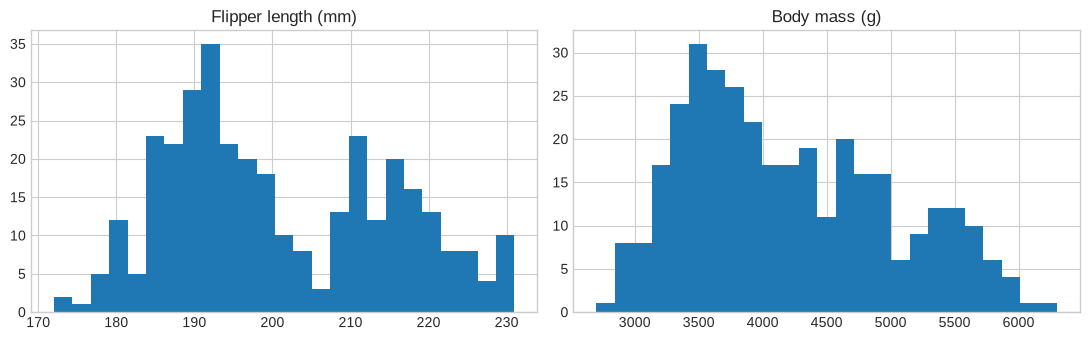

In [5]:
# One histogram per axes: multiple humps here are not noise, they are the
# three species hiding in one column — the scatter in the next cell proves it.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
pg['flipper_length_mm'].hist(bins=25, ax=axes[0])
axes[0].set_title('Flipper length (mm)')
pg['body_mass_g'].hist(bins=25, ax=axes[1])
axes[1].set_title('Body mass (g)')
plt.tight_layout(); plt.show()

## 5. Species scatter — the visual hypothesis the model will confirm

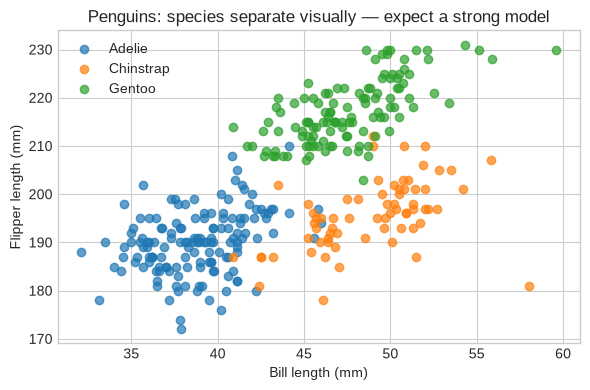

In [6]:
# One color per species on bill-vs-flipper: clusters barely overlap.
# Say it before training: 'if the model does NOT ace this, suspect the
# pipeline, not the data'. dropna() only for plotting (the pipeline imputes).
fig, ax = plt.subplots(figsize=(6, 4))
for sp, grp in pg.dropna().groupby('species'):
    ax.scatter(grp['bill_length_mm'], grp['flipper_length_mm'], label=sp, alpha=0.7)
ax.set_xlabel('Bill length (mm)'); ax.set_ylabel('Flipper length (mm)')
ax.set_title('Penguins: species separate visually — expect a strong model')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Train the classifier — split, shared preprocessor, registry model, fit

In [7]:
# The whole supervised setup in one cell: code-built Config, stratified
# 3-way split (species balance preserved per split), then the standard
# Pipeline the registry saves and the API serves. n_estimators=100 keeps
# this cell to seconds; the CLI example uses 200.
cfg = Config(task='classification')
X = pg.drop(columns=['species']); y = pg['species']
Xtr, _, Xte, ytr, _, yte = split_train_val_test(X, y, cfg, 'classification')
task = get_task('classification')
pipe = Pipeline([('preprocess', task.build_preprocessor(Xtr, cfg)),
                   ('model', build_model(ModelConfig(type='random_forest',
                                   params={'n_estimators': 100}), task.model_registry()))])
pipe.fit(Xtr, ytr)
pred = pipe.predict(Xte)
print(f'trained on {len(Xtr)} rows, scoring {len(Xte)} test rows')

trained on 206 rows, scoring 69 test rows


## 7. Metrics table — the scatter's hypothesis, confirmed in numbers

In [8]:
# evaluate_on_test with no thresholds ({}): metrics only, always 'passed'.
# Multiclass here -> precision/recall/f1 are weighted averages (see
# metrics.py); ROC AUC is binary-only so it is absent — by design, not error.
gate = evaluate_on_test(yte.to_numpy(), pred, None, 'classification', {})
display(pd.Series(gate['metrics']).round(4).to_frame('score'))

,score
accuracy,1.0
precision,1.0
recall,1.0
f1,1.0


## 8. Confusion matrix — where exactly the few errors land

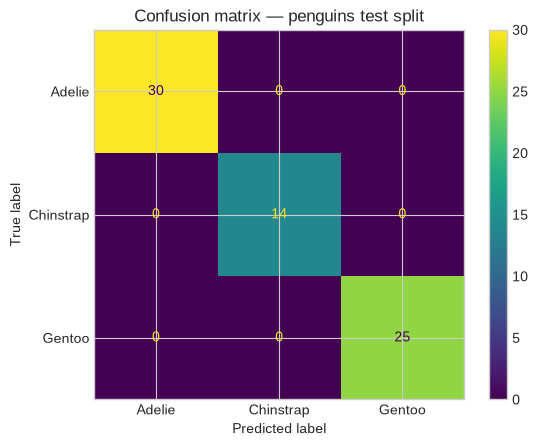

In [9]:
# pipe.classes_ labels the axes in model order. Off-diagonal cells are the
# whole story: Adelie vs Chinstrap mix-ups would point at bill-depth overlap.
ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=pipe.classes_)
plt.title('Confusion matrix — penguins test split'); plt.show()

## 9. Feature importances — what the forest actually leaned on

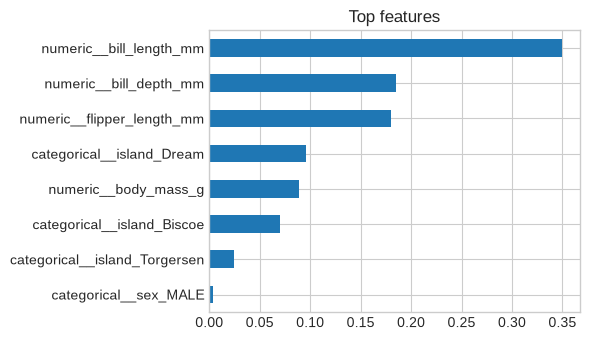

In [10]:
# get_feature_names_out() unrolls the one-hot + scaled names so importances
# stay readable (e.g. categorical__island_Biscoe). Expect flipper/bill on top.
names = pipe.named_steps['preprocess'].get_feature_names_out()
imp = pd.Series(pipe.named_steps['model'].feature_importances_, index=names)
imp.sort_values().tail(8).plot(kind='barh', figsize=(6, 3.5))
plt.title('Top features'); plt.tight_layout(); plt.show()

## 10. Regression CV setup — MPG, 3 folds, small forest (fast cell)

In [11]:
# Second dataset, second task: Auto MPG (398 rows, target = mpg).
# Folds=3 and 50 trees keep this interactive; raise both for real work.
mpg = read_table(str(DATA / 'mpg.csv'))
cfg2 = Config(task='regression')
cfg2.cross_validation.folds = 3
cfg2.model = ModelConfig(type='random_forest', params={'n_estimators': 50})
X2 = mpg.drop(columns=['mpg']); y2 = mpg['mpg']
cv = run_cv(X2, y2, cfg2, 'regression')
print('folds done:', len(cv['per_fold']))

folds done: 3


## 11. Per-fold table — stability across folds, not just the mean

In [12]:
# One row per fold, same metric set as train.py. Read down the r2 column:
# tight cluster = the pipeline is stable; one bad fold = a data pocket the
# model can't handle (slice it next).
display(pd.DataFrame(cv['per_fold']).round(3))

,mae,rmse,r2,mape,smape
0,1.818,2.463,0.898,7.808,7.688
1,2.181,3.216,0.832,9.345,9.135
2,2.092,3.113,0.842,8.830,8.803


## 12. Aggregate table — the numbers you'd quote

In [13]:
# Mean ± std per metric across folds. Quote these, not the single-split
# score: 'R² 0.85 ± 0.06' survives follow-up questions, a bare 0.91 doesn't.
display(pd.DataFrame({k: v for k, v in cv['aggregate'].items()}).round(3))

,mae,rmse,r2,mape,smape
mean,2.030,2.931,0.857,8.661,8.542
std,0.155,0.333,0.029,0.639,0.619


## 13. Train the forecaster — daily births, chronological split, lags inside

In [14]:
# TimeSeriesTask.split builds lag/rolling/date-part features THEN splits
# chronologically, so the test block is strictly after train (no peeking).
# Defaults are daily-shaped (lags 1/7/14); date/target set in code, not YAML.
cfg3 = Config(task='timeseries')
cfg3.data.date_column = 'Date'; cfg3.data.target_column = 'Births'
b = read_table(str(DATA / 'daily-female-births.csv'))
t3 = get_task('timeseries')
Xtr3, Xte3, ytr3, yte3 = t3.split(b, cfg3)
pipe3 = Pipeline([('preprocess', t3.build_preprocessor(Xtr3, cfg3)),
                    ('model', build_model(ModelConfig(type='random_forest',
                                    params={'n_estimators': 100}), t3.model_registry()))])
pipe3.fit(Xtr3, ytr3)
pred3 = pipe3.predict(Xte3)
print(f'history rows: {len(b)} -> train {len(ytr3)} / test {len(yte3)} (post warm-up)')

history rows: 365 -> train 281 / test 70 (post warm-up)


## 14. Forecast metrics — read before looking at the chart

In [15]:
# Negative R²: the forest loses to predicting the mean. Trees can't
# extrapolate flat series well — say so out loud, then show the chart.
# MAPE is fine here (births never near zero); sMAPE is the robust sibling.
m3 = evaluate_on_test(yte3.to_numpy(), pred3, None, 'timeseries', {})
display(pd.Series(m3['metrics']).round(3).to_frame('score'))

,score
mae,6.814
rmse,8.348
r2,-0.643
mape,17.553
smape,15.564


## 15. Forecast chart — the honest picture: flat prediction vs wiggly truth

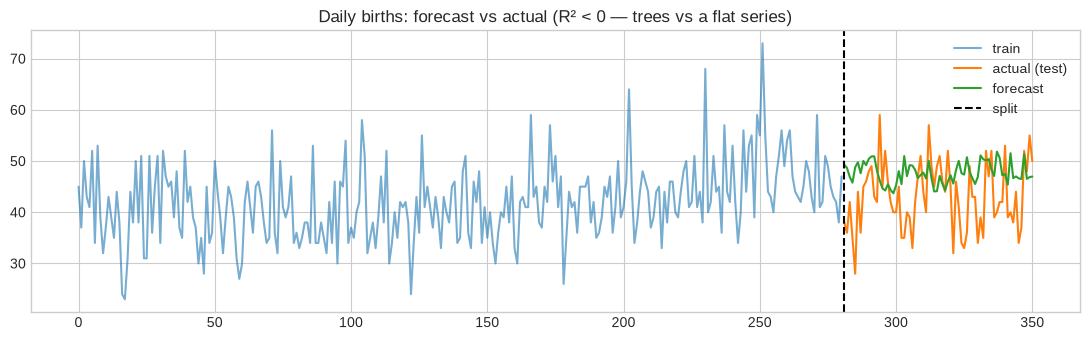

In [16]:
# Train line, test actuals, forecast, and the split boundary. The forecast
# hugs the mean while truth wiggles — that gap IS the negative R² above.
# A gradient-boosted model or an explicit trend feature is the follow-up.
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ytr3.to_numpy(), label='train', alpha=0.6)
ax.plot(range(len(ytr3), len(ytr3) + len(yte3)), yte3.to_numpy(), label='actual (test)')
ax.plot(range(len(ytr3), len(ytr3) + len(yte3)), pred3, label='forecast')
ax.axvline(len(ytr3), color='k', linestyle='--', label='split')
ax.set_title('Daily births: forecast vs actual (R² < 0 — trees vs a flat series)')
ax.legend(); plt.tight_layout(); plt.show()

## 16. Drift table — clean batch scores ~0, injected shift lights up one column

In [17]:
# The reference profile is the same data_distributions dict from the library
# notebook (its 'histograms' are the comparison sample). We triple weight —
# nothing else changes — so exactly one column should cross PSI 0.25.
# Identical data scores ~0 by construction: the method can't cry wolf here.
profile = data_distributions(mpg, 'mpg')
shifted = mpg.copy(); shifted['weight'] = shifted['weight'] * 3
drift_tbl = pd.DataFrame({
    'psi_clean': check_drift(profile, mpg)['psi'],
    'psi_shifted_weight_x3': check_drift(profile, shifted)['psi'],
}).round(4)
display(drift_tbl)
print('PSI > 0.25 = drifted. Only weight moves — exactly as injected.')

,psi_clean,psi_shifted_weight_x3
mpg,0.0,0.0000
cylinders,0.0,0.0000
displacement,0.0,0.0000
horsepower,0.0,0.0000
weight,0.0,12.4221
acceleration,0.0,0.0000
model_year,0.0,0.0000


PSI > 0.25 = drifted. Only weight moves — exactly as injected.
